https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/

In [ ]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from keras.models import Sequential
from sklearn.preprocessing import StandardScaler
from keras.layers import LSTM, Dense, Input
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot
from numpy import sqrt

   Passengers
0         112
1         118
2         132
3         129
4         121
     Passengers
139         606
140         508
141         461
142         390
143         432


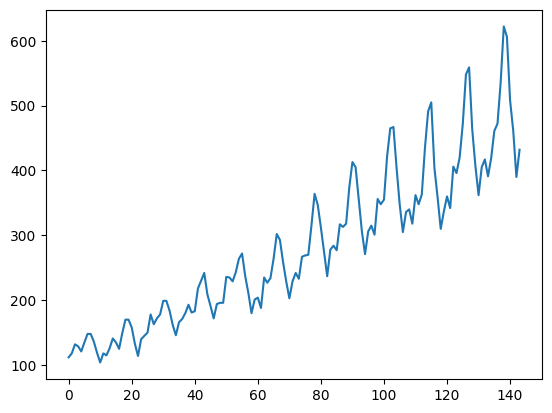

In [ ]:
# Carregar dataset
dataframe = pd.read_csv('airline-passengers.csv', usecols=[1], engine='python')

# Dado um ano e um mês, a tarefa é prever o número de passageiros de voos internacionais
# em unidades de 1.000. Os dados abrangem o período de janeiro de 1949
# a dezembro de 1960, ou seja, 12 anos, com 144 observações.
print(dataframe.head())
print(dataframe.tail())
plt.plot(dataframe)
plt.show()

In [ ]:
# Extrai o array NumPy do dataframe e converte os valores inteiros em
# valores de ponto flutuante, que são mais adequados para modelagem com uma rede neural.
dataset = dataframe.values
dataset = dataset.astype('float32')

print(dataset[0:5])

[[112.]
 [118.]
 [132.]
 [129.]
 [121.]]


In [ ]:
# Divide o conjunto de dados em treino e teste
train_size = int(len(dataset) * 0.7)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
print(len(train), len(test))

100 44


In [ ]:
# Converte o conjunto de dados em um formato para série temporal
# Será uma matriz, onde X é o número de passageiros em um determinado instante (t)
# e Y é o número de passageiros no instante seguinte (t + 1).

# look_back é o número de instantes de tempo anteriores a serem usados ​​como variáveis ​​de entrada
# para prever o próximo período de tempo — neste caso, o valor padrão é 1

def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	return np.array(dataX), np.array(dataY)

In [ ]:
# reshape into X=t and Y=t+1
look_back = 3
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

#print(trainX)

print(np.column_stack((trainX, trainY)))

[[112. 118. 132. 129.]
 [118. 132. 129. 121.]
 [132. 129. 121. 135.]
 [129. 121. 135. 148.]
 [121. 135. 148. 148.]
 [135. 148. 148. 136.]
 [148. 148. 136. 119.]
 [148. 136. 119. 104.]
 [136. 119. 104. 118.]
 [119. 104. 118. 115.]
 [104. 118. 115. 126.]
 [118. 115. 126. 141.]
 [115. 126. 141. 135.]
 [126. 141. 135. 125.]
 [141. 135. 125. 149.]
 [135. 125. 149. 170.]
 [125. 149. 170. 170.]
 [149. 170. 170. 158.]
 [170. 170. 158. 133.]
 [170. 158. 133. 114.]
 [158. 133. 114. 140.]
 [133. 114. 140. 145.]
 [114. 140. 145. 150.]
 [140. 145. 150. 178.]
 [145. 150. 178. 163.]
 [150. 178. 163. 172.]
 [178. 163. 172. 178.]
 [163. 172. 178. 199.]
 [172. 178. 199. 199.]
 [178. 199. 199. 184.]
 [199. 199. 184. 162.]
 [199. 184. 162. 146.]
 [184. 162. 146. 166.]
 [162. 146. 166. 171.]
 [146. 166. 171. 180.]
 [166. 171. 180. 193.]
 [171. 180. 193. 181.]
 [180. 193. 181. 183.]
 [193. 181. 183. 218.]
 [181. 183. 218. 230.]
 [183. 218. 230. 242.]
 [218. 230. 242. 209.]
 [230. 242. 209. 191.]
 [242. 209.

In [ ]:
print(trainX.shape)
print(trainY.shape)

(96, 3)
(96,)


In [ ]:
# Criamos dois objetos separados: um para as entradas (X) e outro para as saídas (y).
# Isso é vital porque o X tem várias colunas/passos e o y é apenas o valor alvo.
# Ter um scaler_y exclusivo permite usar o inverse_transform() no futuro para ver os valores reais.
scaler_X = StandardScaler()
scaler_y = StandardScaler()

trainX_scaled = scaler_X.fit_transform(trainX)
testX_scaled = scaler_X.transform(testX)

trainY_scaled = scaler_y.fit_transform(trainY.reshape(-1, 1))
testY_scaled = scaler_y.transform(testY.reshape(-1, 1))

print(trainX_scaled[0:5])
print(testX_scaled[0:5])

[[-1.421646   -1.3680524  -1.202187  ]
 [-1.3377799  -1.1722624  -1.2442561 ]
 [-1.1420925  -1.2142174  -1.3564408 ]
 [-1.1840255  -1.3260974  -1.1601177 ]
 [-1.2958469  -1.1303076  -0.97781765]]
[[1.974929  2.883384  3.4674988]
 [2.911433  3.4847386 3.495545 ]
 [3.512473  3.5127084 2.6120908]
 [3.5404284 2.6316543 1.8127753]
 [2.6598349 1.8345098 1.2238059]]


In [ ]:
# A rede LSTM espera que os dados de entrada (X) sejam fornecidos com uma estrutura de array específica
# no formato: [amostras, passos de tempo, características].
# Atualmente, nossos dados estão no formato: [amostras, características] e estamos formulando
# o problema como um passo de tempo para cada amostra.
# Podemos transformar os dados de entrada de treinamento e teste preparados na
# estrutura esperada usando numpy.reshape() da seguinte forma:
print(trainX_scaled.shape)
print(testX_scaled.shape)
#trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
#testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

# reshape a entrada para [amostras, intervalos de tempo, características] (aumentar o número de intervalos de tempo por amostra).
trainX_scaled = np.reshape(trainX_scaled, (trainX_scaled.shape[0], trainX_scaled.shape[1], 1))
testX_scaled = np.reshape(testX_scaled, (testX_scaled.shape[0], testX_scaled.shape[1], 1))
print(trainX_scaled[1])
print(trainX_scaled.shape)
print(trainY_scaled.shape)

(96, 3)
(40, 3)
[[-1.3377799]
 [-1.1722624]
 [-1.2442561]]
(96, 3, 1)
(96, 1)


In [ ]:
print(trainX_scaled[0:5,])
print(trainY_scaled[0:5,])

[[[-1.421646  ]
  [-1.3680524 ]
  [-1.202187  ]]

 [[-1.3377799 ]
  [-1.1722624 ]
  [-1.2442561 ]]

 [[-1.1420925 ]
  [-1.2142174 ]
  [-1.3564408 ]]

 [[-1.1840255 ]
  [-1.3260974 ]
  [-1.1601177 ]]

 [[-1.2958469 ]
  [-1.1303076 ]
  [-0.97781765]]]
[[-1.2625169]
 [-1.3734311]
 [-1.1793311]
 [-0.9990953]
 [-0.9990953]]


In [ ]:
# create and fit the LSTM network
model = Sequential()
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(40))
model.add(Dense(20, activation='leaky_relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

history = model.fit(trainX_scaled, trainY_scaled, epochs=100, batch_size=10, verbose=1, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step - loss: 0.6424 - val_loss: 1.8979
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5051 - val_loss: 1.6874
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4135 - val_loss: 1.4549
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3213 - val_loss: 1.2461
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2494 - val_loss: 1.0281
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1907 - val_loss: 0.8463
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1667 - val_loss: 0.6730
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1567 - val_loss: 0.5465
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1487 - val_loss: 0.4776
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1420 - val_loss: 0.4383
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1402 - val_loss: 0.4112
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1389 - val_l

In [ ]:
# Plota a curva de aprendizado
def plot_learning_curve():
  pyplot.title('Learning Curves')
  pyplot.xlabel('Epoch')
  pyplot.ylabel('Error')
  pyplot.plot(history.history['loss'], label='train')
  pyplot.plot(history.history['val_loss'], label='val')
  pyplot.legend()
  pyplot.show()

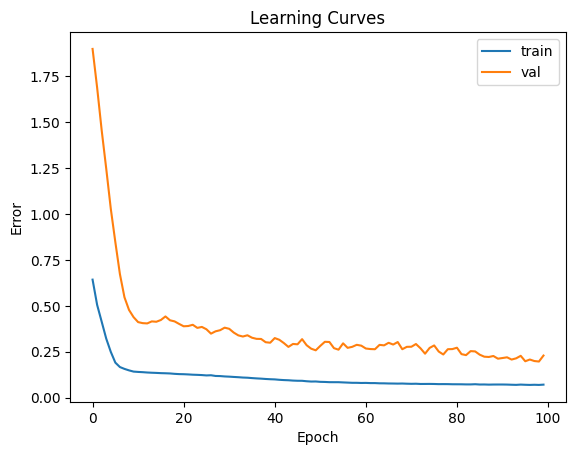

In [ ]:
plot_learning_curve()

In [ ]:
# Avalia o modelo
mse = model.evaluate(testX_scaled, testY_scaled, verbose=0)
print('MSE: %.3f, RMSE: %.3f' % (mse, sqrt(mse)))

MSE: 0.995, RMSE: 0.998


In [ ]:
# make predictions
trainPredict_scaled = model.predict(trainX_scaled)
testPredict_scaled = model.predict(testX_scaled)

print(testPredict_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
[[2.4903011 ]
 [2.1376224 ]
 [1.1741412 ]
 [1.2292628 ]
 [0.87784475]
 [1.7610388 ]
 [1.2550704 ]
 [0.87133265]
 [2.096324  ]
 [1.0157725 ]
 [1.8031855 ]
 [2.9460392 ]
 [2.8122735 ]
 [2.4823833 ]
 [0.637443  ]
 [1.7414418 ]
 [0.7943552 ]
 [1.7721853 ]
 [1.6657112 ]
 [1.0197476 ]
 [2.7431178 ]
 [1.279395  ]
 [2.448359  ]
 [2.9789062 ]
 [3.6287296 ]
 [2.6944983 ]
 [1.2133827 ]
 [2.086989  ]
 [1.4624803 ]
 [2.7030063 ]
 [1.8761144 ]
 [1.4012654 ]
 [2.5980651 ]
 [2.7332335 ]
 [2.3054123 ]
 [3.728814  ]
 [4.1725383 ]
 [2.6700516 ]
 [1.7451923 ]
 [2.6700232 ]]


In [ ]:
# Desfaz a escala usando o scaler do 'y'
test_predictions_original = scaler_y.inverse_transform(testPredict_scaled)
train_predictions_original = scaler_y.inverse_transform(trainPredict_scaled)

In [ ]:
# Compara predições com valores verdadeiros
y_test_original = scaler_y.inverse_transform(testY_scaled)

print(np.hstack((y_test_original, test_predictions_original)))

[[467.      399.6823 ]
 [404.      374.2444 ]
 [347.      304.75067]
 [305.      308.72647]
 [336.      283.37946]
 [340.      347.08228]
 [318.      310.58792]
 [362.      282.90976]
 [348.      371.26562]
 [363.      293.32788]
 [435.      350.12222]
 [491.      432.55368]
 [505.      422.90546]
 [404.      399.1112 ]
 [359.      266.03983]
 [310.      345.6688 ]
 [337.      277.35754]
 [360.      347.88623]
 [342.      340.2065 ]
 [406.      293.6146 ]
 [396.      417.91742]
 [420.      312.34238]
 [472.      396.65714]
 [548.      434.92432]
 [559.      481.79462]
 [463.      414.4106 ]
 [407.      307.58105]
 [362.      370.59232]
 [405.      325.5479 ]
 [417.      415.02426]
 [391.      355.38242]
 [419.      321.13263]
 [461.      407.45508]
 [472.      417.20447]
 [535.      386.3467 ]
 [622.      489.01346]
 [606.      521.0183 ]
 [508.      412.64734]
 [461.      345.9393 ]
 [390.      412.64526]]


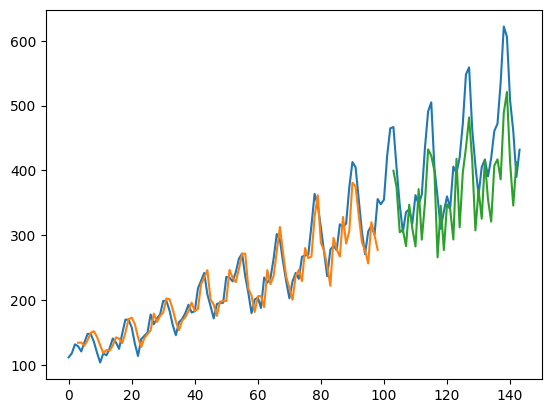

In [ ]:
# Devido à forma como o conjunto de dados foi preparado, precisamos ajustar as previsões
# para que fiquem alinhadas no eixo x com o conjunto de dados original.

# Depois de preparados, os dados são plotados, mostrando o conjunto de dados original em azul,
# as previsões para o conjunto de dados de treinamento em laranja,
# e as previsões para o conjunto de dados de teste não visto em verde.

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predictions_original)+look_back, :] = train_predictions_original

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predictions_original)+(look_back*2)+1:len(dataset)-1, :] = test_predictions_original

# plot baseline and predictions
plt.plot(dataset)
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()